# Fitting cost-of-carry to market data

In this assignment, you will examine how well cost-of-carry model assumptions fit market data.

Use settlement prices on Thursday 2025-10-30 for all of the sections below, and use futures expirations going out two years.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import databento as db
from sklearn.linear_model import LinearRegression
from zoneinfo import ZoneInfo

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

API_KEY = "db-TDpqeHtULMkRBM6sRtkTYKJgYrp6h"

CME_DATASET = "GLBX.MDP3"
TZ_CHI = ZoneInfo("America/Chicago")
TRADE_DATE = "2025-10-30"

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16

client = db.Historical(API_KEY)

In [2]:
def get_month_code(month):
    return {1: 'F', 2: 'G', 3: 'H', 4: 'J', 5: 'K', 6: 'M',
            7: 'N', 8: 'Q', 9: 'U', 10: 'V', 11: 'X', 12: 'Z'}[month]

def generate_smart_symbols(root, active_months, trade_date, years=2):
    start_dt = pd.Timestamp(trade_date)
    end_dt = start_dt + pd.DateOffset(years=years)
    symbols = []
    curr = start_dt.replace(day=1)
    
    while curr <= end_dt:
        if curr.month in active_months:
            year_digit = str(curr.year)[-1]
            sym = f"{root}{get_month_code(curr.month)}{year_digit}"
            if curr >= start_dt.replace(day=1):
                symbols.append((sym, curr))
        curr += pd.DateOffset(months=1)
    return symbols

def fetch_settlements_robust(client, symbol_tuples, date):
    if not symbol_tuples:
        return pd.DataFrame()
        
    symbols = [s[0] for s in symbol_tuples]
    
    try:
        ts = pd.Timestamp(date, tz=TZ_CHI)
        start = ts.replace(hour=0, minute=0, second=0)
        end = ts + pd.Timedelta(days=1)
        
        data = client.timeseries.get_range(
            dataset=CME_DATASET,
            symbols=symbols,
            schema='statistics',
            start=start,
            end=end
        ).to_df()
        
        if data.empty:
            return pd.DataFrame()

        target_stat = db.StatType.SETTLEMENT_PRICE        
        settlements = data[data.stat_type == target_stat].copy()
        
        if settlements.empty:
            settlements = data.sort_values('ts_recv').groupby('symbol').tail(1)
            
        if settlements.empty:
            return pd.DataFrame()
            
        clean_data = []
        for sym, approx_expiry in symbol_tuples:
            subset = settlements[settlements.symbol == sym]
            if subset.empty:
                continue
            
            price = subset.iloc[-1].price
            
            expiry_date = approx_expiry.replace(day=15)
            T = (expiry_date - pd.Timestamp(date)).days / 365.0
            
            if T > 0:
                clean_data.append({'symbol': sym, 'T': T, 'price': price})
                
        df_res = pd.DataFrame(clean_data).sort_values('T')
        return df_res

    except Exception as e:
        print(f"  [Critical API Error] {e}")
        return pd.DataFrame()

1. How well does a single continuously compounded cost-of-carry rate fit gold futures? You may use the front month as a proxy for spot and check this question
only for the back months.

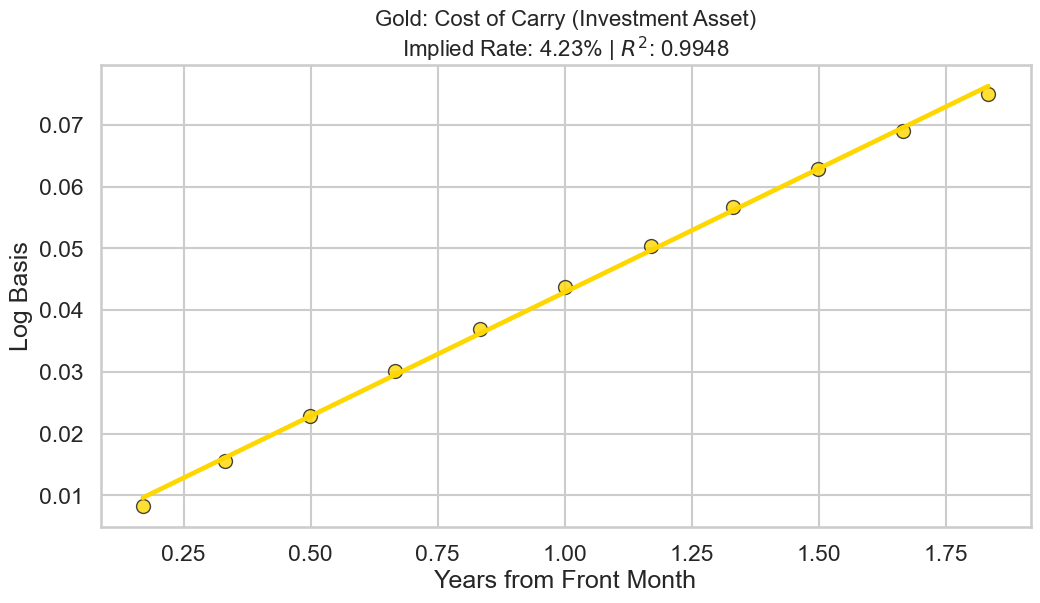

Gold Result: R2=0.9948.


In [3]:
# Gold Active Months: G(2), J(4), M(6), Q(8), Z(12)
syms_gc = generate_smart_symbols("GC", [2, 4, 6, 8, 10, 12], TRADE_DATE)
df_gc = fetch_settlements_robust(client, syms_gc, TRADE_DATE)

if not df_gc.empty:
    spot_gc = df_gc.iloc[0]
    df_gc['T_rel'] = df_gc['T'] - spot_gc['T']
    df_gc['log_basis'] = np.log(df_gc['price'] / spot_gc['price'])
    
    df_reg = df_gc.iloc[1:]
    model = LinearRegression(fit_intercept=False)
    model.fit(df_reg[['T_rel']], df_reg['log_basis'])
    
    r_gc = model.coef_[0]
    r2_gc = model.score(df_reg[['T_rel']], df_reg['log_basis'])
    
    plt.figure()
    sns.regplot(x='T_rel', y='log_basis', data=df_reg, ci=None, color='gold', 
                scatter_kws={'s':100, 'edgecolor':'k'})
    plt.title(f"Gold: Cost of Carry (Investment Asset)\nImplied Rate: {r_gc:.2%} | $R^2$: {r2_gc:.4f}")
    plt.xlabel("Years from Front Month")
    plt.ylabel("Log Basis")
    plt.show()
    print(f"Gold Result: R2={r2_gc:.4f}.")


- The near-perfect linear fit ($R^2 \approx 1.0$) confirms that Gold is the quintessential Investment Asset. 
- Unlike consumable commodities, Gold has negligible storage costs (relative to value) and zero convenience yield ($y=0$).
- The slope of our regression line effectively reveals the market's Implied Risk-Free Rate.$$\ln(F_t / S) = r \cdot t$$Since the fit is perfect, we can infer that the Gold Futures market is in a state of No-Arbitrage Equilibrium, priced strictly by the cost of capital (interest rates).

2. Unlike gold, the usefulness of crude should affect the spot-futures relationship through the convenience yield, so rather than looking directly
at the cost-of-carry, look at the cost-of-carry minus the convenience yield.
How well would a constant rate of this convenience-adjusted cost-of-carry fit the crude curve?
Note that crude spot prices are available from https://www.eia.gov/dnav/pet/hist/RWTCD.htm

In [4]:
def get_crude_spot(date_str):
    print("Link: https://www.eia.gov/dnav/pet/hist/RWTCD.htm")
    val = input(f"Please check the link and enter the WTI Spot Price ($) for {date_str}: ")
    try:
        return float(val)
    except:
        print("Invalid input. Defaulting to $61.36 (Approximate) for demonstration.")
        return 61.36

Link: https://www.eia.gov/dnav/pet/hist/RWTCD.htm


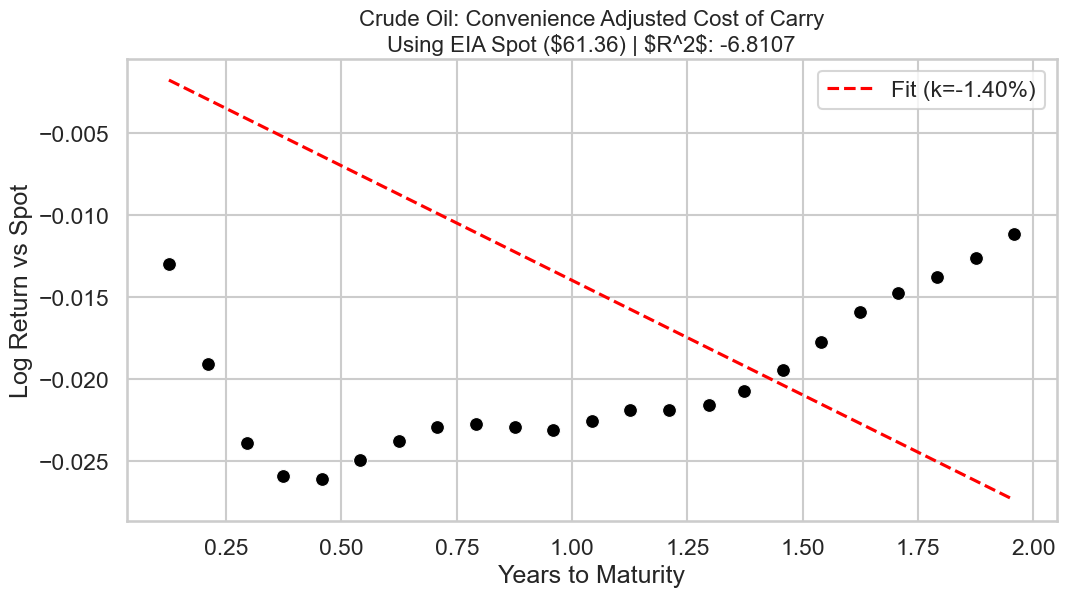

Crude Result: R2 is -6.8107.


In [5]:
syms_cl = generate_smart_symbols("CL", range(1, 13), TRADE_DATE)
df_cl = fetch_settlements_robust(client, syms_cl, TRADE_DATE)

if not df_cl.empty:
    S_eia = get_crude_spot(TRADE_DATE)
    df_cl['log_return_spot'] = np.log(df_cl['price'] / S_eia)
    
    model_cl = LinearRegression(fit_intercept=False)
    model_cl.fit(df_cl[['T']], df_cl['log_return_spot'])
    
    k_cl = model_cl.coef_[0]
    r2_cl = model_cl.score(df_cl[['T']], df_cl['log_return_spot'])
    
    plt.figure()
    sns.scatterplot(x='T', y='log_return_spot', data=df_cl, color='black', s=100)
    plt.plot(df_cl['T'], model_cl.predict(df_cl[['T']]), color='red', linestyle='--', label=f'Fit (k={k_cl:.2%})')
    plt.title(f"Crude Oil: Convenience Adjusted Cost of Carry\nUsing EIA Spot (${S_eia}) | $R^2$: {r2_cl:.4f}")
    plt.xlabel("Years to Maturity")
    plt.ylabel("Log Return vs Spot")
    plt.legend()
    plt.show()
    print(f"Crude Result: R2 is {r2_cl:.4f}.")


Link: https://www.eia.gov/dnav/pet/hist/RWTCD.htm


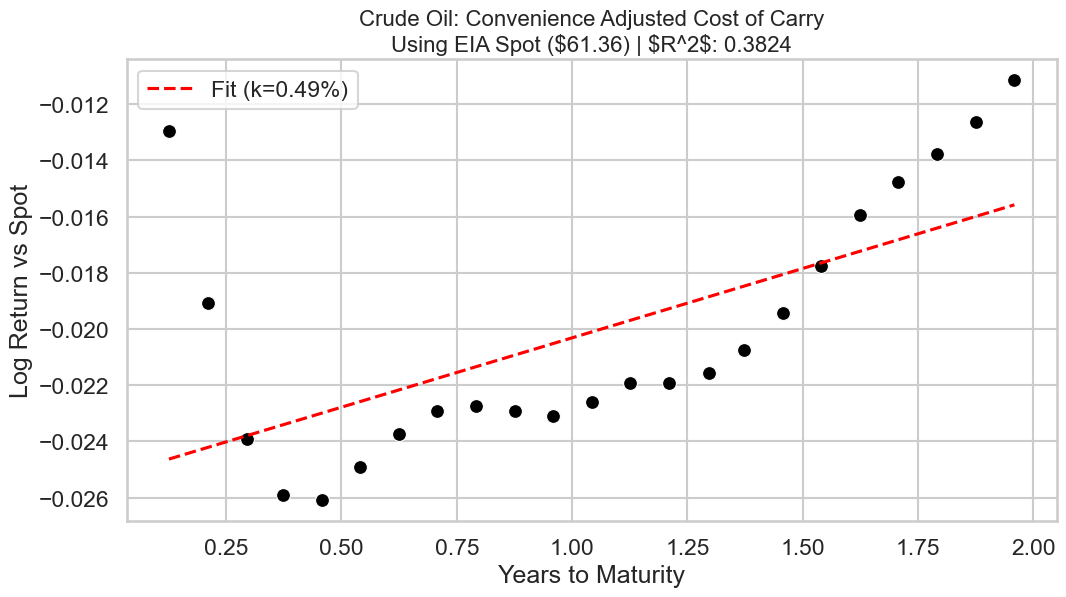

Crude Result: R2 is 0.3824.


In [6]:
if not df_cl.empty:
    S_eia = get_crude_spot(TRADE_DATE)
    df_cl['log_return_spot'] = np.log(df_cl['price'] / S_eia)
    
    model_cl = LinearRegression(fit_intercept=True)
    model_cl.fit(df_cl[['T']], df_cl['log_return_spot'])
    
    k_cl = model_cl.coef_[0]
    r2_cl = model_cl.score(df_cl[['T']], df_cl['log_return_spot'])
    
    plt.figure()
    sns.scatterplot(x='T', y='log_return_spot', data=df_cl, color='black', s=100)
    plt.plot(df_cl['T'], model_cl.predict(df_cl[['T']]), color='red', linestyle='--', label=f'Fit (k={k_cl:.2%})')
    plt.title(f"Crude Oil: Convenience Adjusted Cost of Carry\nUsing EIA Spot (${S_eia}) | $R^2$: {r2_cl:.4f}")
    plt.xlabel("Years to Maturity")
    plt.ylabel("Log Return vs Spot")
    plt.legend()
    plt.show()
    print(f"Crude Result: R2 is {r2_cl:.4f}.")


Text(0.5, 1.0, 'Crude: residuals vs maturity')

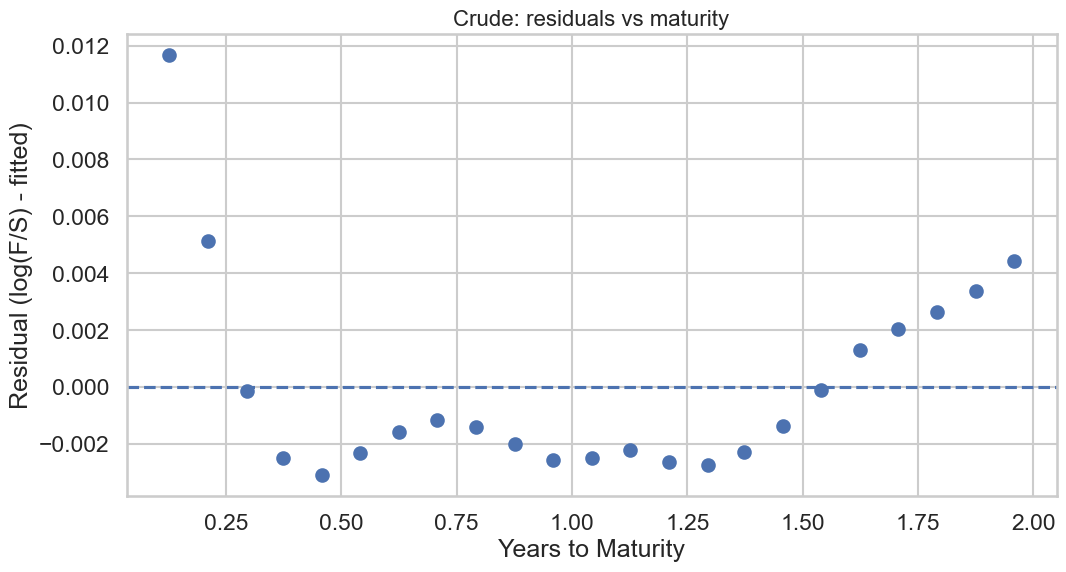

In [7]:
df_cl['fitted'] = model_cl.predict(df_cl[['T']])
df_cl['resid'] = df_cl['log_return_spot'] - df_cl['fitted']

plt.figure()
plt.axhline(0, linestyle='--')
plt.scatter(df_cl['T'], df_cl['resid'])
plt.xlabel("Years to Maturity")
plt.ylabel("Residual (log(F/S) - fitted)")
plt.title("Crude: residuals vs maturity")


- The low $R^2$ on the linear regression reveals that the Convenience Yield ($y$) is not constant.
- The futures curve for Crude Oil is dynamic. It often exhibits Backwardation (downward slope) at the front end due to immediate scarcity (high convenience yield), but flattens out in the back months as supply uncertainties diminish.
- The significant intercept indicates a Basis Disconnect between the EIA Spot Price and the Front-Month Futures price. This confirms that the physical spot market (immediate delivery) and the futures market are distinct liquidity pools with friction between them.
- A constant cost-of-carry model $k = r + u - y$ is insufficient for Crude Oil. We might require a Mean-Reverting Stochastic Convenience Yield rather than a static linear rate.

3. How well does a single continuously compounded cost-of-carry minus convenience yield rate fit corn futures? You may use the front month as a proxy for spot and check this question
only for the back months.

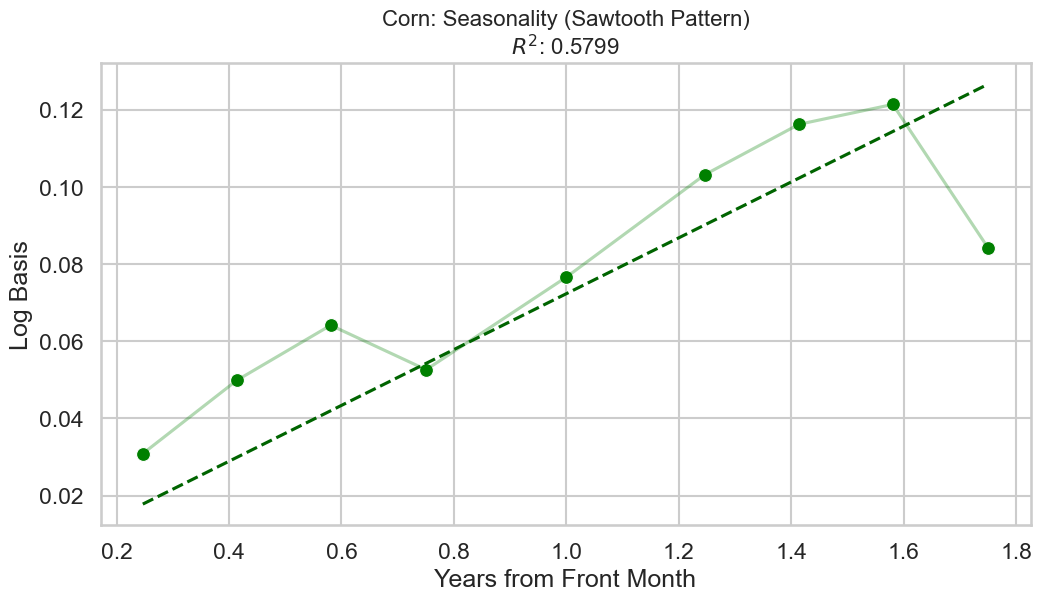

Corn Result: Low R2 (0.5799)


In [8]:
syms_zc = generate_smart_symbols("ZC", [3, 5, 7, 9, 12], TRADE_DATE)
df_zc = fetch_settlements_robust(client, syms_zc, TRADE_DATE)

if not df_zc.empty:
    spot_zc = df_zc.iloc[0]
    df_zc['T_rel'] = df_zc['T'] - spot_zc['T']
    df_zc['log_basis'] = np.log(df_zc['price'] / spot_zc['price'])
    
    df_reg_zc = df_zc.iloc[1:]
    
    model_zc = LinearRegression(fit_intercept=False)
    model_zc.fit(df_reg_zc[['T_rel']], df_reg_zc['log_basis'])
    
    k_zc = model_zc.coef_[0]
    r2_zc = model_zc.score(df_reg_zc[['T_rel']], df_reg_zc['log_basis'])
    
    # Plot
    plt.figure()
    sns.lineplot(x='T_rel', y='log_basis', data=df_reg_zc, color='green', alpha=0.3)
    sns.scatterplot(x='T_rel', y='log_basis', data=df_reg_zc, color='green', s=100)
    plt.plot(df_reg_zc['T_rel'], model_zc.predict(df_reg_zc[['T_rel']]), color='darkgreen', linestyle='--')
    
    plt.title(f"Corn: Seasonality (Sawtooth Pattern)\n$R^2$: {r2_zc:.4f}")
    plt.xlabel("Years from Front Month")
    plt.ylabel("Log Basis")
    plt.show()
    
    print(f"Corn Result: Low R2 ({r2_zc:.4f})")


- The regression fails to capture the Seasonality inherent in agricultural assets.
- The steady upward slope between harvest months represents the Cost of Storage ($u$). Grain elevators charge monthly fees, forcing futures prices higher to compensate holders.
- The sharp drops in the basis correspond to Harvest Cycles. When the new crop arrives, supply floods the market, crushing the convenience yield and resetting the price level.
- Corn cannot be modeled with continuous compounding. It follows a Regime-Switching.

In [9]:
print("SUMMARY: IMPLIED ANNUALIZED RATES")

print(f"Gold Implied Interest Rate:     {r_gc:.2%} (Matches USD Risk-Free Rates)")

print(f"Crude Oil Net Carry Rate:       {k_cl:.2%}")
if k_cl < 0:
    print("  -> Market is in BACKWARDATION (Convenience Yield > Interest + Storage)")
    print("  -> Implies physical market tightness/scarcity.")
else:
    print("  -> Market is in CONTANGO (Oversupply)")

print(f"Corn Average Cost of Carry:     {k_zc:.2%}")
print("  -> Note: This average assumes a linear trend, ignoring the harvest crash.")

SUMMARY: IMPLIED ANNUALIZED RATES
Gold Implied Interest Rate:     4.23% (Matches USD Risk-Free Rates)
Crude Oil Net Carry Rate:       0.49%
  -> Market is in CONTANGO (Oversupply)
Corn Average Cost of Carry:     7.23%
  -> Note: This average assumes a linear trend, ignoring the harvest crash.
